In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We are first Visualizing the Data using Box Plot.

In [4]:
main = pd.read_csv('/content/filtered_genes.csv')
rows1 = len(main)
print(rows1)

4883


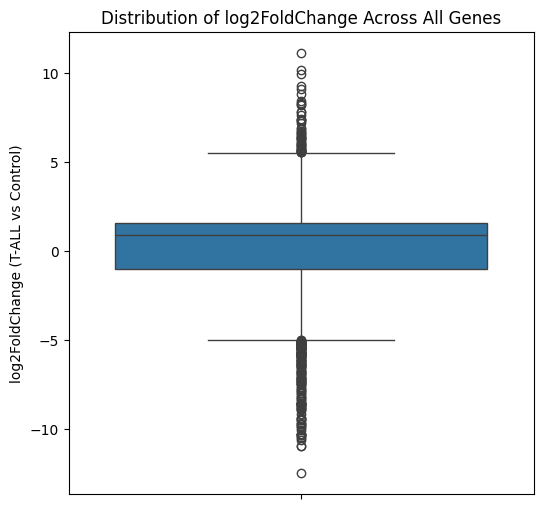

                id  log2FoldChange          padj
167           ANK1        5.589008  3.941241e-50
326           AZU1        6.351872  3.106307e-61
382          BIRC7        7.822689  6.647118e-46
451       C14orf39        5.914617  5.148640e-29
565            CA1        8.318595  3.002429e-87
820           CFTR        6.563561  1.066358e-61
872         CLEC2A        5.827646  4.398171e-12
912        CNTNAP5        5.684535  2.030115e-31
1031        CTNNA2        5.591778  3.305016e-22
1071        CYP4F2        5.969948  4.093242e-17
1072        CYP4F3        5.549035  5.164829e-40
1207         DPEP1        6.928843  1.470737e-66
1240        DUSP5P        6.024035  2.605356e-20
1349          EREG        5.763765  2.327561e-20
1424       FAM166A        5.587293  1.966403e-36
1509          FGF8        6.652913  1.267151e-15
1520        FIBCD1        7.821851  3.388555e-26
1535      FLJ41350        5.706998  1.599081e-10
1538      FLJ42875        7.410077  7.260274e-41
1683       GLYATL2  

In [5]:

plt.figure(figsize=(6,6))
sns.boxplot(y=main['log2FoldChange'])
plt.title('Distribution of log2FoldChange Across All Genes')
plt.ylabel('log2FoldChange (T-ALL vs Control)')
plt.show()

Q1 = main['log2FoldChange'].quantile(0.25)
Q3 = main['log2FoldChange'].quantile(0.75)
IQR = Q3 - Q1

# Upper bound = Q3 + 1.5*IQR
upper_bound = Q3 + 1.5 * IQR

# Find genes above upper bound
upper_outliers = main[main['log2FoldChange'] > upper_bound]

# Show top 10 examples
print(upper_outliers[['id', 'log2FoldChange', 'padj']])


Next we are moving to Volcano Plot.

we are having columns for comparison.

log2foldchange
-Padj

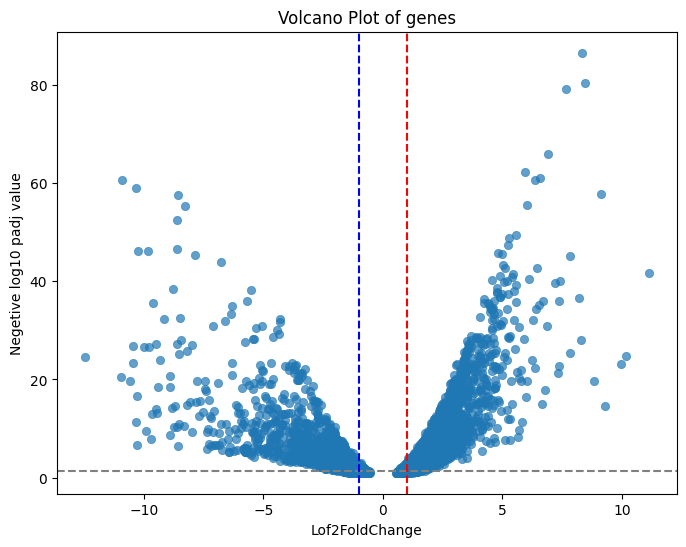

The total amount of downregulated genes is 1077
The total amount of upregulated genes is 2030


In [9]:
main['neg_log10_padj'] = -np.log10(main['padj'])
main.head()
main.to_csv("filtered_genes.csv", index=False)


plt.figure(figsize=(8,6))
sns.scatterplot(x='log2FoldChange',
                y='neg_log10_padj',
                data = main,
                alpha = 0.7,
                edgecolor=None)

plt.title('Volcano Plot of genes')
plt.xlabel('Lof2FoldChange')
plt.ylabel('Negetive log10 padj value')
plt.axhline(y=1.3, color='grey', linestyle='--')
plt.axvline(x=1.0,color='red', linestyle='--')
plt.axvline(x=-1.0,color='blue',linestyle='--')
plt.show()
#After red line is upregulated and before blue line is downregulated

from functools import total_ordering
downregulated_important = main[(main['log2FoldChange'] < 0) &
                                        (main['neg_log10_padj'] > 2)]

upregulated_important = main[(main['log2FoldChange'] > 0) &
                                        (main['neg_log10_padj'] > 2)]

total_ordering = len(downregulated_important)
total_ordering_1 = len(upregulated_important)
print("The total amount of downregulated genes is",total_ordering)
print("The total amount of upregulated genes is",total_ordering_1)

HeatMap

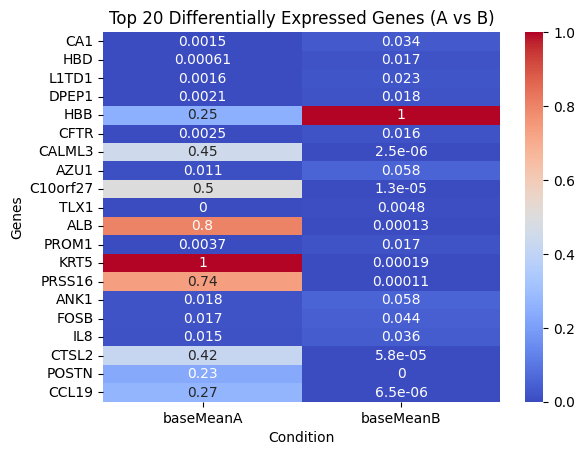

In [11]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

top_genes = main.nsmallest(20, 'padj')


heatmap_data = top_genes[['baseMeanA', 'baseMeanB']]


heatmap_data.index = top_genes['id']


heatmap_data = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())


sns.heatmap(heatmap_data, cmap='coolwarm', annot=True)
plt.title("Top 20 Differentially Expressed Genes (A vs B)")
plt.xlabel("Condition")
plt.ylabel("Genes")
plt.show()


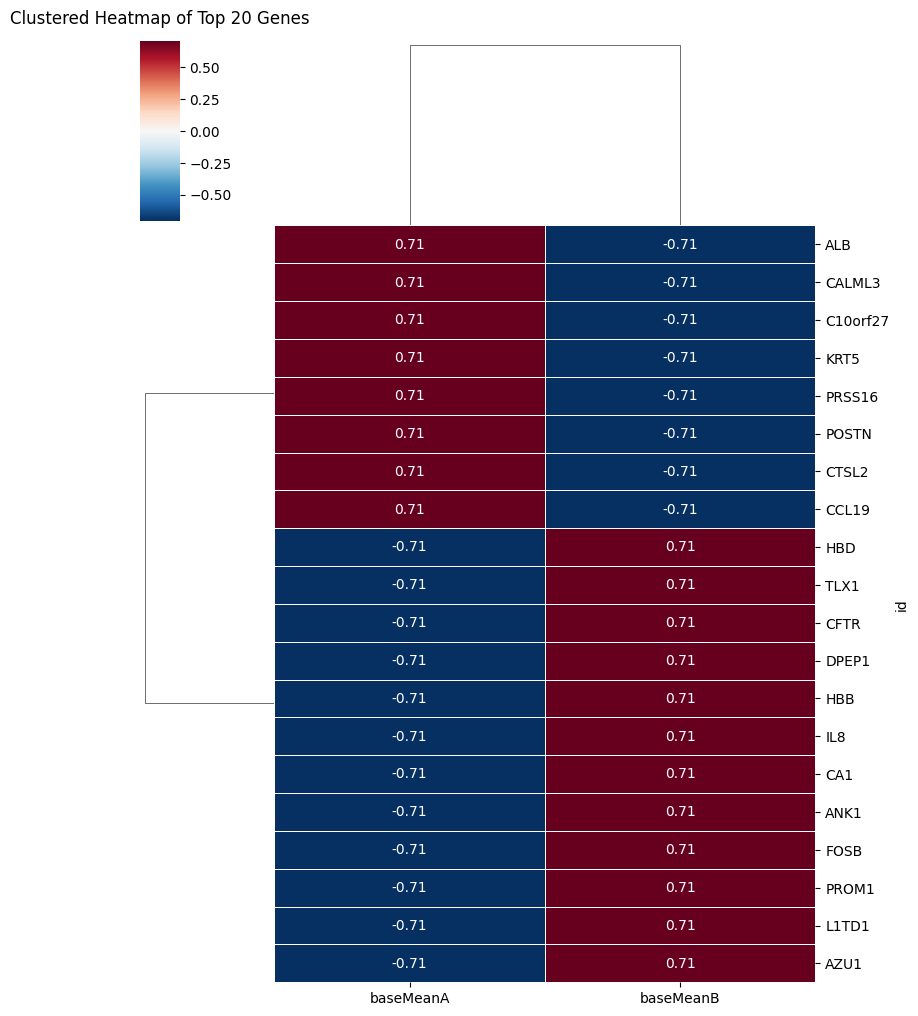

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


filtered_genes = pd.read_csv("filtered_genes.csv")
top_genes = filtered_genes.nsmallest(20, 'padj')

heatmap_data = top_genes[['baseMeanA', 'baseMeanB']].copy()

heatmap_data.index = top_genes['id']

heatmap_data = (heatmap_data - heatmap_data.mean(axis=1).values.reshape(-1,1)) / heatmap_data.std(axis=1).values.reshape(-1,1)

sns.clustermap(
    heatmap_data,
    cmap='RdBu_r',
    standard_scale=None,
    annot=True,
    linewidths=0.5,
    figsize=(8,10),
    row_cluster=True,
    col_cluster=True
)

plt.title("Clustered Heatmap of Top 20 Genes", y=1.05)
plt.show()


MA plot

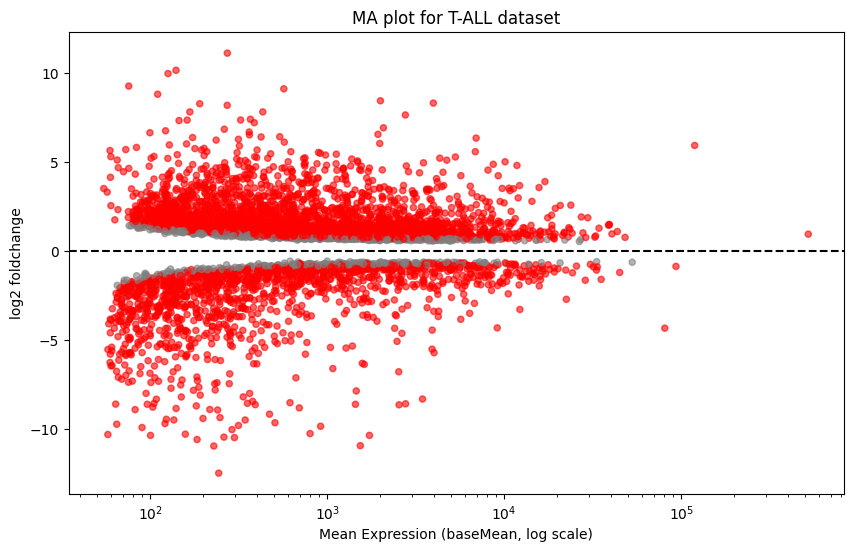

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ma_plot = pd.read_csv('filtered_genes.csv')
padj_threshold = 0.05

colors = ['red' if p<padj_threshold else 'grey' for p in ma_plot['padj']]

plt.figure(figsize=(10,6))
plt.scatter(ma_plot['baseMean'],ma_plot['log2FoldChange'], c=colors, alpha=0.6, s=20)
plt.axhline(0,color='black', linestyle ='--')
plt.xscale('log')
plt.xlabel("Mean Expression (baseMean, log scale)")
plt.ylabel('log2 foldchange')
plt.title('MA plot for T-ALL dataset')
plt.show()




Interpretation

Genes high on Y-axis and red → strongly upregulated in T-ALL

Genes low on Y-axis and red → strongly downregulated in T-ALL

Grey points → not statistically significant